<a href="https://colab.research.google.com/github/enilt/langgraph-alura/blob/main/Aula_02_Componentes_Groq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 02 — Componentes (LangGraph) com Groq

**Adaptado do curso Alura "Orquestração de agentes e multiagentes com LangGraph" (Aula 02 – Componentes).**

Aqui mantemos o **LangGraph** (que é o tema da aula: `StateGraph`, nós, arestas condicionais),
mas aplicamos as mesmas adaptações que fizemos na Aula 01:

- **Groq** no lugar do Google Gemini (usando `langchain-groq` / `ChatGroq`).
- Busca da chave em **3 lugares** (`get_secret`): variável de ambiente, Secrets do Colab e `.env`.
- Modelo **`openai/gpt-oss-120b`** (substituto recomendado após a desativação dos modelos Llama na Groq).
- Chamada de ferramentas **nativa** via `bind_tools` (robusta com os modelos de raciocínio).

> **As perguntas e os prompts foram mantidos exatamente iguais aos do notebook original.**
> Funciona no **Google Colab** e no **VS Code** (com `.env`).

## 1. Instalação das dependências

Trocamos os pacotes do Google pelos da Groq. Mantemos `langgraph` e a busca `langchain-tavily`.

In [1]:
%pip install -q langgraph langchain-groq langchain-tavily python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.6 MB/s eta 0:00:00


## 2. Configurar as chaves de API

Precisamos de duas chaves:
- **`GROQ_API_KEY`** → <https://console.groq.com/keys>
- **`TAVILY_API_KEY`** → <https://app.tavily.com> (busca na web)

A função `get_secret` procura cada chave em três lugares (variável de ambiente → Secrets do
Colab → arquivo `.env`), então o mesmo notebook roda no Colab e no VS Code sem alterar código.

In [2]:
import os

def get_secret(nome: str) -> str:
    """Busca um segredo em: variavel de ambiente -> Colab Secrets -> arquivo .env."""
    valor = os.environ.get(nome)
    if valor:
        return valor
    try:
        from google.colab import userdata  # type: ignore
        valor = userdata.get(nome)
        if valor:
            return valor
    except Exception:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()
        valor = os.environ.get(nome)
        if valor:
            return valor
    except Exception:
        pass
    raise RuntimeError(
        f"Nao encontrei o segredo '{nome}'. Configure de uma destas formas:\n"
        f"  - Colab: icone da chave na lateral, nome {nome}\n"
        f"  - VS Code: crie um arquivo .env com {nome}=sua_chave\n"
        f"  - Terminal: export {nome}=sua_chave"
    )

# Disponibiliza as chaves como variaveis de ambiente (langchain-groq e tavily leem daqui)
os.environ["GROQ_API_KEY"] = get_secret("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = get_secret("TAVILY_API_KEY")
print("Chaves carregadas com sucesso!")

Chaves carregadas com sucesso!


## 3. Importações

No lugar de `ChatGoogleGenerativeAI` usamos `ChatGroq`. A busca continua com `TavilySearch`
(do pacote `langchain-tavily`).

In [3]:
from typing import TypedDict, Annotated, List
import operator

from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langchain_core.messages import (
    AnyMessage, BaseMessage, SystemMessage, HumanMessage, ToolMessage,
)

## 4. A ferramenta de busca (Tavily)

In [4]:
tool = TavilySearch(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_tavily.tavily_search.TavilySearch'>
tavily_search


## 5. O estado do agente

O estado guarda a lista de mensagens. O `operator.add` faz com que novas mensagens sejam
**acumuladas** (em vez de substituídas) a cada passo do grafo.

In [5]:
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

## 6. A classe `Agent` (o grafo LangGraph)

Esta é a mesma estrutura da aula: um nó `llm` (chama o modelo), um nó `action` (executa a
ferramenta) e uma aresta condicional que decide se ainda há ferramenta a chamar. A única
mudança real é que o método que chama o modelo agora fala com a **Groq** (por isso o renomeamos
de `call_gemini` para `call_llm`).

In [6]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_llm)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_llm(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

## 7. Prompt, modelo e montagem do agente

O **prompt é exatamente o mesmo** do notebook original. Só trocamos o modelo para a Groq.

Atenção: a Groq desativou os modelos Llama no plano gratuito — usamos `openai/gpt-oss-120b`.
Como ele é um modelo de raciocínio, passamos `reasoning_effort="low"`.

In [7]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

MODELO_GROQ = "openai/gpt-oss-120b"

model = ChatGroq(
    model=MODELO_GROQ,
    temperature=0,
    reasoning_effort="low",  # gpt-oss sao modelos de raciocinio (passe direto, NAO em model_kwargs)
)

abot = Agent(model, [tool], system=prompt)

## 8. Visualizar o grafo

Assim como na aula, dá para ver a estrutura do grafo em Mermaid.

In [8]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



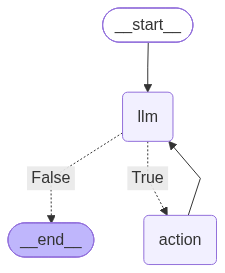

In [9]:
from IPython.display import Image, display

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Erro ao tentar gerar PNG do Mermaid: {e}")
    print("\nUse `.draw_mermaid()` para obter a string e visualizar externamente.")

## 9. Rodando o agente (mesma pergunta do notebook original)

Vamos acompanhar a execução passo a passo com `stream`.

In [10]:
messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Need current weather. Use search.', 'tool_calls': [{'id': 'fc_181faf48-0a76-458e-b4ac-8a07aaed8124', 'function': {'arguments': '{"query":"tempo hoje São Paulo","search_depth":"fast","time_range":"day"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 395, 'total_tokens': 451, 'completion_time': 0.119059115, 'completion_tokens_details': {'reasoning_tokens': 8}, 'prompt_time': 0.018166493, 'prompt_tokens_details': None, 'queue_time': 0.033297261, 'total_time': 0.137225608}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_068241849b', 'service_tier': 'on_demand', 'reasoning_effort': 'low', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d4b5-7056-7ec1-bac6-89163c5b0dfe-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo hoje

## 10. Prompt com a data atual

Este é o segundo prompt do notebook original (também mantido igual): ele injeta a data de
hoje para o agente priorizar informações em tempo real. Reconstruímos o `abot` com esse prompt.

In [11]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y")  # Formato dd/mm/aaaa

prompt = f"""Você é um assistente de pesquisa inteligente e altamente atualizado. \
Sua principal prioridade é encontrar as informações mais RECENTES e em TEMPO REAL sempre que possível. \
A data atual é {current_date}. \
Ao buscar sobre o tempo ou eventos que se referem a "hoje" ou "agora", \
você DEVE **incluir a data atual '{current_date}' na sua consulta para a ferramenta de busca**. \
Por exemplo, se a pergunta é "tempo em cidade x hoje", a consulta para a ferramenta deve ser "tempo em cidade x {current_date}". \
Ignore ou descarte informações que claramente se refiram a datas passadas ou futuras ao responder perguntas sobre "hoje". \
Use o mecanismo de busca para procurar informações, sempre buscando o 'hoje' ou o 'agora' quando o contexto indicar. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model = ChatGroq(model=MODELO_GROQ, temperature=0, reasoning_effort="low")
abot = Agent(model, [tool], system=prompt)

user_query = "Como está o tempo em São Paulo hoje?"
messages = [HumanMessage(content=user_query)]

print("Iniciando interação do agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to search weather São Paulo 24/09/2026.', 'tool_calls': [{'id': 'fc_149e7803-d825-48d7-86d6-848187e40313', 'function': {'arguments': '{"query":"tempo em São Paulo 24/09/2026","search_depth":"fast","time_range":"day"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 553, 'total_tokens': 624, 'completion_time': 0.152562246, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.026803579, 'prompt_tokens_details': None, 'queue_time': 0.07418764, 'total_time': 0.179365825}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bb691ea66b', 'service_tier': 'on_demand', 'reasoning_effort': 'low', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d4b5-7887-72e2-bc6e-b51bf00e9e9b-0', tool_calls=[{'name': 'tavily_search', 'args'

### Pergunta sobre "amanhã" (mesma do notebook original)

In [12]:
user_query_tomorrow = "Como está o tempo em São Paulo amanhã?"  # atualizamos apenas a pergunta do usuario
messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente para amanha ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para amanha ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado para amanha.")


--- Iniciando interação do agente para amanha ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to search weather São Paulo tomorrow, include date. Use query "tempo em São Paulo amanhã 24/09/2026".', 'tool_calls': [{'id': 'fc_0696f4fc-c47b-4374-8ab0-ad749d2dabae', 'function': {'arguments': '{"query":"tempo em São Paulo amanhã 24/09/2026","search_depth":"fast","time_range":"day"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 553, 'total_tokens': 638, 'completion_time': 0.181777565, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.035923368, 'prompt_tokens_details': None, 'queue_time': 0.132170816, 'total_time': 0.217700933}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4200b3f836', 'service_tier': 'on_demand', 'reasoning_effort': 'low', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

### Pergunta sobre "ontem" (mesma do notebook original)

In [13]:
user_query_tomorrow = "Como foi o tempo em São Paulo ontem?"
messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")


--- Iniciando interação do agente ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Need search with date 23/09/2026.', 'tool_calls': [{'id': 'fc_01e384f6-760f-44e1-862d-bcbb77ca0790', 'function': {'arguments': '{"query":"clima São Paulo 23/09/2026","search_depth":"advanced","time_range":"day"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 553, 'total_tokens': 621, 'completion_time': 0.147196475, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.023037109, 'prompt_tokens_details': None, 'queue_time': 0.150656024, 'total_time': 0.170233584}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f640395b96', 'service_tier': 'on_demand', 'reasoning_effort': 'low', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d4b5-89fa-7830-84b5-e75151d91c11-0', tool_calls=[{'name': 'tavily_search', 'args': {'

## 11. Olhando os detalhes

Então, vamos chamar novamente este agente, perguntando: "Qual é o tempo em SP hoje?".
Dessa vez, vamos olhar em detalhes o que o agente buscou e como ele o fez.

In [14]:
messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'tempo em São Paulo 24/09/2026', 'search_depth': 'fast', 'time_range': 'day'}, 'id': 'fc_2b6f757b-7d78-42c4-b7ac-678dbc5ac0c0', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search', 'args': {'query': 'clima São Paulo 24/09/2026', 'time_range': 'day'}, 'id': 'fc_8cde0f66-82e6-458f-9533-f7ad4f172aa6', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search', 'args': {'query': 'tempo São Paulo 24/09/2026', 'search_depth': 'fast', 'time_range': 'day'}, 'id': 'fc_ae96a80b-8c70-4581-bd92-a69ba37abcab', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search', 'args': {'query': 'tempo São Paulo 24/09/2026'}, 'id': 'fc_3b23319d-5cea-4c8e-83e9-3c4c0d70bbc0', 'type': 'tool_call'}
Back to the model!


In [15]:
result['messages'][-1].content

'Desculpe, mas no momento não consigo acessar a ferramenta de busca para obter a previsão meteorológica em tempo real. Para saber como está o tempo em São\u202fPaulo hoje (24/09/2026), recomendo consultar um dos serviços de meteorologia atualizados, como:\n\n- **Climatempo** – https://www.climatempo.com.br  \n- **Weather.com** – https://weather.com/pt-BR/tempo/hoje/l/BRXX0205:1:BR  \n- **AccuWeather** – https://www.accuweather.com/pt/br/sao-paulo/347622/weather-forecast/347622  \n\nNesses sites você pode inserir “São\u202fPaulo” e a data de hoje (24/09/2026) para obter a temperatura atual, sensação térmica, probabilidade de chuva, velocidade do vento e demais detalhes.  \n\nSe precisar de ajuda para interpretar a previsão ou comparar diferentes fontes, estou à disposição!'

## 12. Próximos passos (N8N)

Este desenho — modelo Groq + ferramenta de busca + grafo de decisão — é exatamente o que o
nó **AI Agent** do N8N faz internamente. Ao migrar, você recria o modelo (Groq), conecta a
ferramenta Tavily e usa o mesmo prompt. As chaves ficam nas *credentials* do N8N em vez do `.env`.